## 1. SparkSession - entry point

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import Window
from pyspark.sql.types import (StructType, StructField, IntegerType, DoubleType, StringType)

import pandas as pd
import matplotlib.pyplot as plt

spark = (
    SparkSession.builder
        .appName("NinjaTraderETL")
        .master("local[*]")  # use all cores on machine as workers
        .config("spark.jars.packages", "com.microsoft.sqlserver:mssql-jdbc:12.8.1.jre11")
        .getOrCreate()
)

spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/08/26 17:12:38 WARN Utils: Your hostname, caroline.local, resolves to a loopback address: 127.0.0.1; using 192.168.0.188 instead (on interface en0)
26/08/26 17:12:38 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
:: loading settings :: url = jar:file:/Users/drew/code/data-eng/.venv/lib/python3.14/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /Users/drew/.ivy2.5.2/cache
The jars for the packages stored in: /Users/drew/.ivy2.5.2/jars
com.microsoft.sqlserver#mssql-jdbc added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-11a79488-4256-401e-82f9-78251d5c0768;1.0
	confs: [default]
	found com.microsoft.sqlserver#mssql-jdbc;12.8.1.jre11 in central
:: resolution report :: resolve 62ms :: artifacts dl 1ms
	:: modules in use:
	com.microsoft.sqlserver#mssql-jdbc;12.8.1.jre11 from central in 

## 2. Extract — read the raw CSV with an explicit schema (bronze layer)

In [2]:
raw_schema = StructType([
    StructField("trade_number", IntegerType(), True),
    StructField("qty", IntegerType(), True),
    StructField("entry_price", DoubleType(), True),
    StructField("exit_price", DoubleType(), True),
    StructField("entry_time_raw", StringType(), True),
    StructField("exit_time_raw", StringType(), True),
    StructField("entry_name", StringType(), True),
    StructField("exit_name", StringType(), True),
    StructField("profit_raw", StringType(), True),
    StructField("cum_net_profit_raw", StringType(), True),
    StructField("mae_raw", StringType(), True),
    StructField("mfe_raw", StringType(), True),
    StructField("bars", IntegerType(), True),
    StructField("_trailing", StringType(), True) # ninjatrader exports a trailing comma
])

bronze_df = (
    spark.read
    .option("header", True)
    .schema(raw_schema)
    .csv("trades.csv")
)

print(f"row count: {bronze_df.count()}")
bronze_df.printSchema()
bronze_df.show(5, truncate=False)

row count: 158
root
 |-- trade_number: integer (nullable = true)
 |-- qty: integer (nullable = true)
 |-- entry_price: double (nullable = true)
 |-- exit_price: double (nullable = true)
 |-- entry_time_raw: string (nullable = true)
 |-- exit_time_raw: string (nullable = true)
 |-- entry_name: string (nullable = true)
 |-- exit_name: string (nullable = true)
 |-- profit_raw: string (nullable = true)
 |-- cum_net_profit_raw: string (nullable = true)
 |-- mae_raw: string (nullable = true)
 |-- mfe_raw: string (nullable = true)
 |-- bars: integer (nullable = true)
 |-- _trailing: string (nullable = true)

+------------+---+-----------+----------+--------------------+--------------------+--------------+-------------+----------+------------------+-------+-------+----+---------+
|trade_number|qty|entry_price|exit_price|entry_time_raw      |exit_time_raw       |entry_name    |exit_name    |profit_raw|cum_net_profit_raw|mae_raw|mfe_raw|bars|_trailing|
+------------+---+-----------+----------+--

26/08/26 17:12:43 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: Trade number, Qty, Entry price, Exit price, Entry time, Exit time, Entry name, Exit name, Profit, Cum. net profit, MAE, MFE, Bars, 
 Schema: trade_number, qty, entry_price, exit_price, entry_time_raw, exit_time_raw, entry_name, exit_name, profit_raw, cum_net_profit_raw, mae_raw, mfe_raw, bars, _trailing
Expected: trade_number but found: Trade number
CSV file: file:///Users/drew/code/data-eng/learn/smbc-spark/trades.csv


## 3. Transform — clean types, parse currency, derive columns (silver layer)

In [3]:
def parse_currency(colname: str):
    """convert ninjatrader-formatted currency stirngs like '$850.00' / '($850.00)' to signed double"""
    c = F.col(colname)
    is_negative = c.startswith("(")
    stripped = F.regexp_replace(c, r"[\$,()]","")
    numeric = stripped.cast("double")
    return F.when(is_negative, -numeric).otherwise(numeric)

TS_FORMAT = "M/d/yyyy h:mm:ss a"

silver_df = (
    bronze_df
    .withColumn("entry_time", F.to_timestamp("entry_time_raw", TS_FORMAT))
    .withColumn("exit_time", F.to_timestamp("exit_time_raw", TS_FORMAT))
    .withColumn("profit", parse_currency("profit_raw"))
    .withColumn("mae", parse_currency("mae_raw"))
    .withColumn("mfe", parse_currency("mfe_raw"))
    .withColumn(
        "side",
        F.when(F.col("entry_name").contains("long"), "long")
         .when(F.col("entry_name").contains("short"), "short")
         .otherwise("unknown")
    )
    .withColumn(
        "duration_minutes",
        (F.col("exit_time").cast("long") - F.col("entry_time").cast("long")) / 60.0
    )
    .withColumn("is_win", F.col("profit") > 0)
    .select(
        "trade_number", "qty", "side", "entry_price", "exit_price", "entry_time", "exit_time", "duration_minutes",
        "bars", "exit_name", "profit", "mae", "mfe", "is_win"
    )
)

silver_df.printSchema()
silver_df.orderBy("trade_number").show(10, truncate=False)

root
 |-- trade_number: integer (nullable = true)
 |-- qty: integer (nullable = true)
 |-- side: string (nullable = false)
 |-- entry_price: double (nullable = true)
 |-- exit_price: double (nullable = true)
 |-- entry_time: timestamp (nullable = true)
 |-- exit_time: timestamp (nullable = true)
 |-- duration_minutes: double (nullable = true)
 |-- bars: integer (nullable = true)
 |-- exit_name: string (nullable = true)
 |-- profit: double (nullable = true)
 |-- mae: double (nullable = true)
 |-- mfe: double (nullable = true)
 |-- is_win: boolean (nullable = true)

+------------+---+-----+-----------+----------+-------------------+-------------------+------------------+----+-------------+------+-----+-----+------+
|trade_number|qty|side |entry_price|exit_price|entry_time         |exit_time          |duration_minutes  |bars|exit_name    |profit|mae  |mfe  |is_win|
+------------+---+-----+-----------+----------+-------------------+-------------------+------------------+----+-------------+

26/08/26 17:12:43 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: Trade number, Qty, Entry price, Exit price, Entry time, Exit time, Entry name, Exit name, Profit, MAE, MFE, Bars
 Schema: trade_number, qty, entry_price, exit_price, entry_time_raw, exit_time_raw, entry_name, exit_name, profit_raw, mae_raw, mfe_raw, bars
Expected: trade_number but found: Trade number
CSV file: file:///Users/drew/code/data-eng/learn/smbc-spark/trades.csv


## 4. Gold layer — window functions for cumulative P&L and drawdown

In [4]:
trade_order = Window.orderBy("trade_number").rowsBetween(Window.unboundedPreceding, Window.currentRow)

gold_df = (
    silver_df
    .withColumn("cum_net_profit", F.round(F.sum("profit").over(trade_order), 2))
    .withColumn("running_max_equity", F.max("cum_net_profit").over(trade_order))
    .withColumn("drawdown",  F.round(F.col("cum_net_profit") - F.col("running_max_equity"), 2))
)

gold_df.select(
    "trade_number", "entry_time", "side", "profit", "cum_net_profit", "drawdown"
).orderBy("trade_number").show(10, truncate=False)

max_drawdown = gold_df.agg(F.min("drawdown")).first()[0]
print(f"max drawdown (spark-computed): ${max_drawdown:,.2f}")

26/08/26 17:12:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/08/26 17:12:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/08/26 17:12:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/08/26 17:12:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/08/26 17:12:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/08/26 17:12:44 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: Trade number, Entry time, Entry name, Profit
 Schema: trade_number, entry_time_raw

+------------+-------------------+-----+------+--------------+--------+
|trade_number|entry_time         |side |profit|cum_net_profit|drawdown|
+------------+-------------------+-----+------+--------------+--------+
|1           |2026-01-02 10:07:50|short|850.0 |850.0         |0.0     |
|2           |2026-01-05 09:36:11|short|-850.0|0.0           |-850.0  |
|3           |2026-01-06 09:41:30|short|-850.0|-850.0        |-1700.0 |
|4           |2026-01-07 09:33:59|short|-350.0|-1200.0       |-2050.0 |
|5           |2026-01-08 09:31:19|short|-662.5|-1862.5       |-2712.5 |
|6           |2026-01-09 09:45:21|short|850.0 |-1012.5       |-1862.5 |
|7           |2026-01-12 10:04:42|short|-300.0|-1312.5       |-2162.5 |
|8           |2026-01-13 09:30:19|short|850.0 |-462.5        |-1312.5 |
|9           |2026-01-14 09:30:19|long |-850.0|-1312.5       |-2162.5 |
|10          |2026-01-15 09:36:40|short|-125.0|-1437.5       |-2287.5 |
+------------+-------------------+-----+------+--------------+--

26/08/26 17:12:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/08/26 17:12:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/08/26 17:12:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/08/26 17:12:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/08/26 17:12:44 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: Trade number, Profit
 Schema: trade_number, profit_raw
Expected: trade_number but found: Trade number
CSV file: file:///Users/drew/code/data-eng/learn/smbc-spark/trades.csv
26/08/26 17:12:44 WARN WindowExec: No Partition Defined for Window operati

## 5. Summary statistics — groupBy / agg

In [5]:
summary_by_side = (
    gold_df.groupBy("side")
    .agg(
        F.count("*").alias("num_trades"),
        F.round(F.avg(F.col("is_win").cast("double")) * 100, 2).alias("win_rate_pct"),
        F.round(F.sum(F.when(F.col("profit") > 0, F.col("profit")).otherwise(0.0)), 2).alias("gross_profit"),
        F.round(F.sum(F.when(F.col("profit") < 0, F.col("profit")).otherwise(0.0)), 2).alias("gross_loss"),
        F.round(F.sum("profit"), 2).alias("net_profit"),
        F.round(F.avg(F.when(F.col("profit") > 0, F.col("profit"))), 2).alias("avg_win"),
        F.round(F.avg(F.when(F.col("profit") < 0, F.col("profit"))), 2).alias("avg_loss"),
    )
    .withColumn("profit_factor", F.round(F.col("gross_profit") / F.abs(F.col("gross_loss")), 2))
    .orderBy("side")
)

summary_by_side.show(truncate=False)

overall = gold_df.agg(
    F.count("*").alias("num_trades"),
    F.round(F.avg(F.col("is_win").cast("double")) * 100, 2).alias("win_rate_pct"),
    F.round(F.sum("profit"), 2).alias("net_profit")
)

overall.show(truncate=False)

gold_df.createOrReplaceTempView("trades")

spark.sql("""
    select side, count(*) as num_trades, round(avg(case when is_win then 1.0 else 0.0 end) * 100, 2) as win_rate_pct,
        round(sum(profit),2) as net_profit
    from trades
    group by side
    order by side
""").show(truncate=False)

26/08/26 17:12:44 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: Entry name, Profit
 Schema: entry_name, profit_raw
Expected: entry_name but found: Entry name
CSV file: file:///Users/drew/code/data-eng/learn/smbc-spark/trades.csv
26/08/26 17:12:44 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: Profit
 Schema: profit_raw
Expected: profit_raw but found: Profit
CSV file: file:///Users/drew/code/data-eng/learn/smbc-spark/trades.csv


+-----+----------+------------+------------+----------+----------+-------+--------+-------------+
|side |num_trades|win_rate_pct|gross_profit|gross_loss|net_profit|avg_win|avg_loss|profit_factor|
+-----+----------+------------+------------+----------+----------+-------+--------+-------------+
|long |73        |61.64       |34562.5     |-21537.5  |13025.0   |768.06 |-769.2  |1.6          |
|short|85        |58.82       |39275.0     |-24587.5  |14687.5   |785.5  |-702.5  |1.6          |
+-----+----------+------------+------------+----------+----------+-------+--------+-------------+

+----------+------------+----------+
|num_trades|win_rate_pct|net_profit|
+----------+------------+----------+
|158       |60.13       |27712.5   |
+----------+------------+----------+

+-----+----------+------------+----------+
|side |num_trades|win_rate_pct|net_profit|
+-----+----------+------------+----------+
|long |73        |61.64       |13025.0   |
|short|85        |58.82       |14687.5   |
+-----+---

26/08/26 17:12:45 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: Entry name, Profit
 Schema: entry_name, profit_raw
Expected: entry_name but found: Entry name
CSV file: file:///Users/drew/code/data-eng/learn/smbc-spark/trades.csv


## 6. Load — write the Gold table out

In [6]:
(
    gold_df
    .write
    .mode("overwrite")
    .partitionBy("side")
    .parquet("output/trades_gold")
)

print("wrote gold layer to output/trades_gold/ (partitioned by side (long or short)")

spark.read.parquet("output/trades_gold").count()

# write to local sql server docker

from dotenv import load_dotenv
import os

load_dotenv()  # reads .env in the current working directory into environment variables

sqlserver_host = os.getenv("SQLSERVER_HOST")
sqlserver_port = os.getenv("SQLSERVER_PORT")
sqlserver_db = os.getenv("SQLSERVER_DB")
sqlserver_user = os.getenv("SQLSERVER_USER")
sqlserver_password = os.getenv("SQLSERVER_PASSWORD")

pw = os.getenv("SQLSERVER_PASSWORD")
print(len(pw), pw[0], pw[-1])  # sanity-check password retrieval

jdbc_url = (
    f"jdbc:sqlserver://{sqlserver_host}:{sqlserver_port};"
    f"databaseName={sqlserver_db};"
    "trustServerCertificate=true"  # needed for local Docker SQL Server's self-signed cert
)

(
    gold_df
    .write
    .format("jdbc")
    .option("url", jdbc_url)
    .option("dbtable", "dbo.trades_gold")
    .option("user", sqlserver_user)
    .option("password", sqlserver_password)
    .option("driver", "com.microsoft.sqlserver.jdbc.SQLServerDriver")
    .mode("overwrite")
    .save()
)

print("Wrote gold_df to dbo.trades_gold via JDBC")

26/08/26 17:12:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/08/26 17:12:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/08/26 17:12:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/08/26 17:12:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/08/26 17:12:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/08/26 17:12:45 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: Trade number, Qty, Entry price, Exit price, Entry time, Exit time, Entry name, Exi

wrote gold layer to output/trades_gold/ (partitioned by side (long or short)
9 S 7


26/08/26 17:12:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/08/26 17:12:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/08/26 17:12:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/08/26 17:12:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/08/26 17:12:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/08/26 17:12:46 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToS

Wrote gold_df to dbo.trades_gold via JDBC


## 7. Reproduce the NinjaTrader charts

/Users/drew/code/data-eng/.venv/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
26/08/26 17:12:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/08/26 17:12:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/08/26 17:12:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/08/26 17:12:46 WARN WindowExec: No Partition 

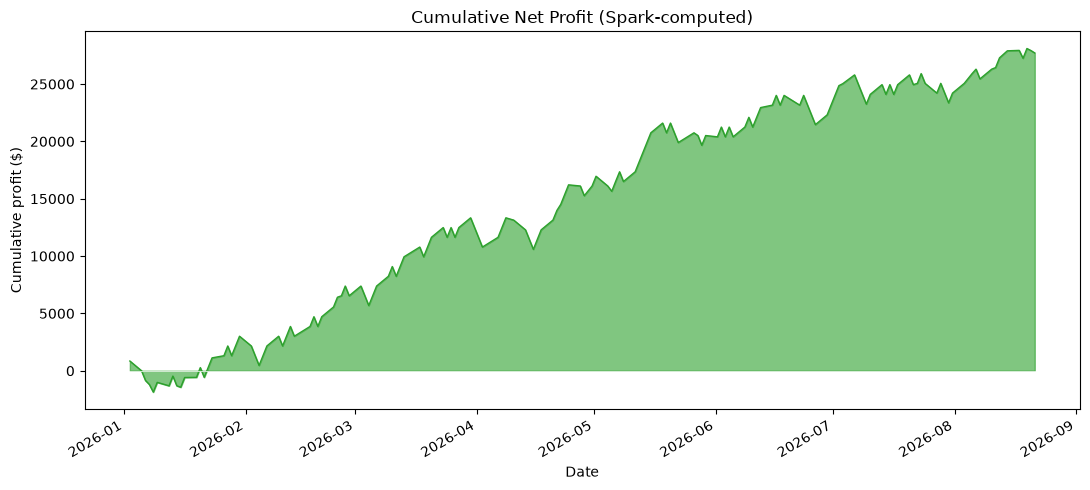

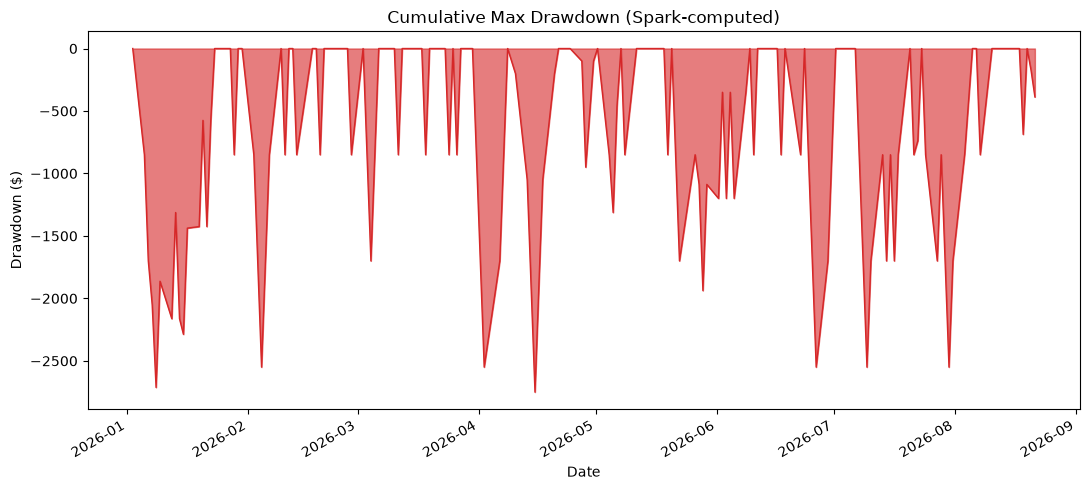

Max drawdown: $-2,750.00   (NinjaTrader reported: ($2,750.00))


In [7]:
plot_pdf = (
    gold_df
    .select("trade_number", "entry_time", "cum_net_profit", "drawdown")
    .orderBy("trade_number")
    .toPandas()
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(plot_pdf["entry_time"], plot_pdf["cum_net_profit"], color="#2ca02c", alpha=0.6)
ax.plot(plot_pdf["entry_time"], plot_pdf["cum_net_profit"], color="#2ca02c", linewidth=1)
ax.set_title("Cumulative Net Profit (Spark-computed)")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative profit ($)")
ax.axhline(0, color="white", linewidth=0.5)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(plot_pdf["entry_time"], plot_pdf["drawdown"], color="#d62728", alpha=0.6)
ax.plot(plot_pdf["entry_time"], plot_pdf["drawdown"], color="#d62728", linewidth=1)
ax.set_title("Cumulative Max Drawdown (Spark-computed)")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown ($)")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"Max drawdown: ${plot_pdf['drawdown'].min():,.2f}   (NinjaTrader reported: ($2,750.00))")